In [3]:
import numpy as np

import multi_aster_spindle as mas
import fit_mt_length_histogram as fmlh

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import argparse
import glob
import os

ceph = '/mnt/home/ealca/ceph/'
home = '/mnt/home/ealca/'

# exp_dir = f'{ceph}multi_aster/useful/spindle_centring_10.0_lbar_5000_tubulin_0.0005_temp'
# exp_dir = f'{ceph}multi_aster/dt-L/single_aster_positioning_2500_tubulin_0.0005_temp'
# exp_dir = f'{ceph}multi_aster/useful/single_aster_positioning_reduced_tub_cost_1000_tubulin_0.002_temp'
# exp_dir = f'{ceph}multi_aster/dt-L/uniform_13_dbar_10000_tubulin_0.0001_temp/'
# exp_dir = f'{ceph}multi_aster/dt-L/test_new_saving_13_dbar_10000_tubulin_0.0002_temp/'
exp_dir = f'{ceph}multi_aster/dt-L/pull_length_alignment_zero_force_13_dbar_10000_tubulin_0.0005_temp/'

spindle = mas.retrieve_experiement(experiment_dir=exp_dir, save_trajectory=True)

start_time = 150
end_time = 240

In [ ]:
def calculate_motor_occupancy(self, mtoc_id, start_time, end_time):

        start_idx = int(np.round(start_time, 4) / self.evolution_time)
        end_idx = int(np.round(end_time, 4) / self.evolution_time)

        spindle_trace_dir = os.path.join(self.dir_path, 'spindle_trace')
        trace_files = sorted(
            glob.glob(os.path.join(spindle_trace_dir, 'spindle_trace_*.npy')),
            key=lambda f: int(os.path.basename(f).split('_')[2])
        )

        pull_state = np.zeros(self.num_pull_sites)
        occupancy = np.zeros(self.num_pull_sites)
        delta_idx = 0

        for trace_file in trace_files:
            changes = np.load(trace_file, allow_pickle=True)
            for push, lattice_site, site_value in changes:
                if delta_idx >= end_idx:
                    break
                if delta_idx >= start_idx:
                    occupancy += (pull_state == mtoc_id).astype(int)
                if not push:
                    pull_state[int(lattice_site)] = site_value
                delta_idx += 1
            if delta_idx >= end_idx:
                break

        num_states = end_idx - start_idx
        if num_states > 0:
            occupancy = occupancy / num_states
        return occupancy

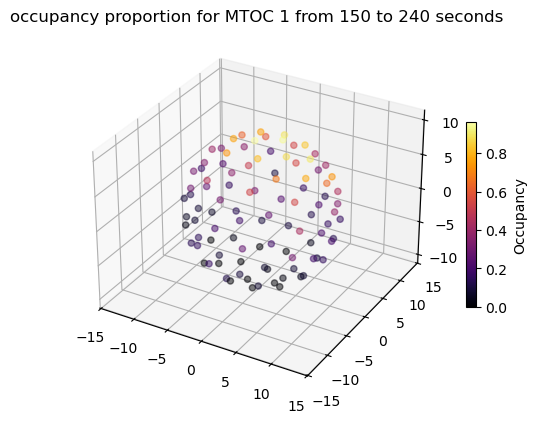

In [4]:
# -- plot heatmap of motor occupancy
pull_lattice = spindle.pull_lattice

xs = pull_lattice[:,0]
ys = pull_lattice[:,1]
zs = pull_lattice[:,2]

# start_time = 55
# end_time = 140

occupancy = spindle.calculate_motor_occupancy(1, start_time, end_time)
norm = mcolors.Normalize(vmin=occupancy.min(), vmax=occupancy.max())

cmap = plt.cm.inferno
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
plt.title(f'occupancy proportion for MTOC 1 from {start_time} to {end_time} seconds')

ax.scatter(xs, ys, zs, c=occupancy,alpha=0.5, cmap=cmap, norm=norm)
ax.axis('equal')

mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array(occupancy)
fig.colorbar(mappable, ax=ax, shrink=0.5, label="Occupancy")
plt.show()